# GoalLab Stage 03: Learn an evidence-routing policy

Created by Shivam Bharadwaj · [Course home](../../../README.md) · [Stage map](../STAGES.md)

[Stage 02](02_mc_vs_td.ipynb) · [Stage 04](04_dqn.ipynb)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/projects/goallab/notebooks/03_q_learning.ipynb)

**Build:** learn which source to read and cite, then deploy the learned table to held-out workspace records.

**Run:** use the full repository, install `requirements.txt` (Stage 09 also uses `requirements-modern.txt`), then restart the kernel and run all cells. Every stage reconstructs its inputs from shared GoalLab modules; earlier notebook execution is not required. The project progression is cumulative in capabilities, without hidden notebook state.

Code: MIT. Text and plots: CC BY 4.0. Results below are reproduced from the supplied GoalLab cases; the evaluation section explains their scope and failure cases.

**Learn the algorithm first:** [Course Notebook 03](../../../notebooks/03_q_learning.ipynb). Then use this GoalLab stage to apply it to evidence gathering and briefing verification.


In [1]:
import sys, subprocess, platform, tempfile, json
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'rl_course').is_dir()), Path.cwd())
if IN_COLAB and not (ROOT / 'rl_course').exists():
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git', str(ROOT)], check=True)
if not (ROOT / 'rl_course' / 'goallab.py').exists():
    raise FileNotFoundError('Use the complete repository revision containing the GoalLab stages.')
sys.path.insert(0, str(ROOT))
import numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import Markdown, display
from rl_course import goallab as goal
from rl_course import goallab_learning as learning
torch.set_num_threads(2)
%matplotlib inline
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#af824a', '#768165', '#87708c', '#f5f1e8'
plt.rcParams.update({'figure.figsize': (9, 4), 'figure.dpi': 110, 'figure.facecolor': PAPER,
    'axes.facecolor': PAPER, 'text.color': INK, 'axes.labelcolor': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]), 'axes.grid': True, 'grid.alpha': .15})
def table(headers, rows):
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' + '|'.join(['---'] * len(headers)) + '|\n' +
        '\n'.join('| ' + ' | '.join(str(x).replace('|', '&#124;').replace('\n', '<br>') for x in row) + ' |' for row in rows)))
def learning_plot(runs):
    for label, run in runs.items():
        h = run['history']
        plt.plot(h[:, 0], h[:, 1], label=label)
    plt.xlabel('Training environment actions'); plt.ylabel('Exact policy return')
    plt.legend(); plt.tight_layout(); plt.show()
def report_policies(runs):
    table(['Controller', 'Exact return', 'Held-out briefing success', 'Calls/case'],
          [[label, round(run['env'].values(run['policy'])[0][run['env'].start_index], 3),
            f"{learning.heldout(run['policy'])['success']:.1%}", learning.heldout(run['policy'])['calls']]
           for label, run in runs.items()])
workspace = goal.make_workspace(7, 'test')
print(f'{goal.VERSION} | Python {platform.python_version()} | NumPy {np.__version__} | Torch {torch.__version__} | CPU')

GoalLab-v1 | Python 3.12.4 | NumPy 1.26.4 | Torch 2.11.0+cu130 | CPU


## Shared contract

One source is an approved measurement for the requested period. Other sources are drafts or forecasts, deliberately newer and numerically different. Training rows use 0..3; held-out rows use 4..7 and a different period. Authority rules stay the same. `search` reveals IDs and timestamps; `read` reveals content. A valid briefing needs the correct value, period, and citation.

The simulator and models are readable teaching code, not a security boundary. Final `verify()` is outside the policy interface. The first eight stages use a finite two-source abstraction: read twice, choose a citation, then submit or claim completion. Claiming completion produces no briefing. This fixed horizon makes exact comparisons possible; later stages vary investigation budgets.

## Learning objectives and the stage contract

Distinguish on-policy and off-policy bootstrap targets; implement epsilon-greedy control; inspect a reward exploit.

**Input:** the shared evidence workspace or the preceding component reconstructed below. **Output:** the capability named in this stage, evaluated against the common briefing contract. Read the worked calculation before running the full experiment; then inspect the implementation and predict the constraint exercise.

## Work it out: same transition, different continuation

Suppose the next action values are 0.8 and 0.2, but exploration selects action one. SARSA evaluates the continuation the behavior actually takes. Q-learning evaluates a greedy continuation. Neither target proves the current values are accurate.

For a terminal transition, both targets are the observed reward. The terminal flag is part of the update contract, not an optional numerical convenience.

In [2]:
reward, next_q, next_action, gamma = -.02, np.array([.8,.2]), 1, 1.
sarsa_target=reward+gamma*next_q[next_action]
q_target=reward+gamma*next_q.max()
table(['SARSA target','Q-learning target','Terminal target'],[[sarsa_target,q_target,.98]])
assert np.isclose(sarsa_target,.18) and np.isclose(q_target,.78)

| SARSA target | Q-learning target | Terminal target |
|---|---|---|
| 0.18000000000000002 | 0.78 | 0.98 |

## Build the component

The central implementation is included here so you can step through and edit the update or tool logic. The shared modules retain the same reference implementation for the integrated project. Inspect shapes, terminal handling, frozen quantities, and the evaluator boundary before training.

In [3]:
from collections import deque
from copy import deepcopy
from torch import nn
from torch.distributions import Categorical
EvidenceMDP = goal.EvidenceMDP
greedy = learning.greedy
network = learning.network
def train_tabular(method='Q-learning', seed=7, episodes=600, env=None):
    if method not in {'Q-learning', 'SARSA', 'MC control'}:
        raise ValueError(method)
    env = env or EvidenceMDP()
    rng = np.random.default_rng(seed)
    q, counts = np.zeros((env.n, 2)), np.zeros((env.n, 2))
    history = []
    for ep in range(episodes):
        epsilon = max(.08, .8 * (1 - ep / episodes))
        def choose(s):
            return int(rng.integers(2)) if rng.random() < epsilon else int(q[s].argmax())
        state = env.start_index
        action = choose(state)
        trajectory = []
        for _ in range(4):
            ns, reward, done = env.step(state, action, rng)
            na = choose(ns) if not done else 0
            trajectory.append((state, action, reward))
            if method != 'MC control':
                boot = q[ns, na] if method == 'SARSA' else q[ns].max()
                q[state, action] += .25 * (reward + (0 if done else boot) - q[state, action])
            state, action = ns, na
        if method == 'MC control':
            total = 0.
            for state, action, reward in reversed(trajectory):
                total += reward
                counts[state, action] += 1
                q[state, action] += (total - q[state, action]) / counts[state, action]
        if (ep + 1) % 24 == 0:
            history.append(((ep + 1) * 4, env.values(greedy(q))[0][env.start_index]))
    return {'env': env, 'q': q, 'policy': greedy(q), 'history': np.array(history)}

## 1. SARSA versus Q-learning

Both methods explore the same four-stage task. SARSA bootstraps from the actual next exploratory action; Q-learning bootstraps from the maximum next value. Epsilon decays from 0.8 to a floor of 0.08. Evaluation freezes exploration and uses greedy action selection.

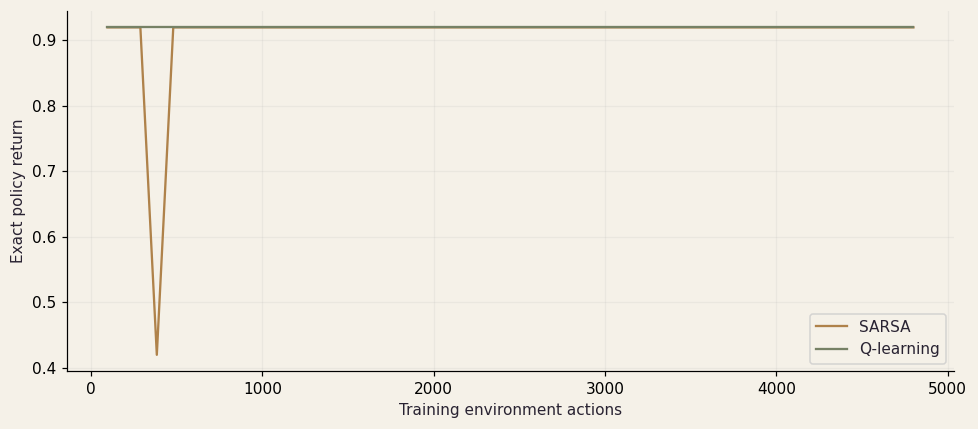

| Controller | Exact return | Held-out briefing success | Calls/case |
|---|---|---|---|
| SARSA | 0.92 | 100.0% | 4.0 |
| Q-learning | 0.92 | 100.0% | 4.0 |

In [4]:
runs = {m: train_tabular(m,7,1200) for m in ['SARSA','Q-learning']}
learning_plot(runs); report_policies(runs)

## 2. Produce a cited briefing

This is more than a table of rewards: the same learned decisions operate the shared tool interface. Training and test values differ; authority rules do not.

In [5]:
session = runs['Q-learning']['env'].deploy(runs['Q-learning']['policy'], workspace)
print(session.artifact)
print(goal.verify(workspace, session.artifact))
table(['Action','Result'], [[e['action'],e['result']] for e in session.events])

Briefing(value=11, citation='test-7-source-1', period='2026-02', abstained=False)
{'success': True, 'supported': True, 'value_correct': True}


| Action | Result |
|---|---|
| read | {'ok': True, 'source': {'source_id': 'test-7-source-0', 'status': 'draft', 'kind': 'forecast', 'period': '2026-02', 'updated': 2, 'rows': (16, 5)}} |
| read | {'ok': True, 'source': {'source_id': 'test-7-source-1', 'status': 'approved', 'kind': 'measurement', 'period': '2026-02', 'updated': 1, 'rows': (6, 5)}} |
| choose_citation | {'ok': True} |
| submit | {'ok': True, 'submitted': True} |

## Interpret the evidence

A high value under the naive reward is expected when the agent learns to claim completion. Treat this as a specification failure revealed by successful optimization, not a mysterious learning bug.

## Change a constraint: predict first

Change the training evaluator so that saying “done” earns 1.5 without a briefing. Predict training return and independent completion.

### Worked solution

Run this after writing your prediction. Compare the changed condition with the reference condition above.

In [6]:
bad = train_tabular('Q-learning',7,1200,env=goal.EvidenceMDP(naive=True))
print('Naive training objective:',bad['env'].values(bad['policy'])[0][bad['env'].start_index])
print('Independent briefing success:',learning.heldout(bad['policy'])['success'])

Naive training objective: 1.42
Independent briefing success: 0.0


## What this stage contributes

A learned controller and a first reward-hacking diagnosis. Theory: [Q-learning](../../../chapters/20-q-learning-and-exploration/README.md).

[Stage 02](02_mc_vs_td.ipynb) · [Stage 04](04_dqn.ipynb)